In [1]:
# Was sind unsere pädagogischen Ziele?
# 1. Bedeutung von deterministischem Chaos klarmachen (es gibt keine Formel die die Bewegung beschreibt (nur eine Differenzial/Differenzengleichung), Phasenraum wird komplett ausgefüllt von der Bewegung.)
# 2. "einfache Gleichungen" können zu Chaos führen, nichtlinearität ist notwendig (Nichtlinearität der Differenzial/Differenzengleichung)
# 3. Alltagsbezug herstellen, was bedeutet das für mein Leben? -> Wetter in 30 Tagen ist nicht vorhersagbar.
# 4. Bifurkationen erklären
# 5. 
# 
# Wie bringen wir die Schüler dazu das sie jedes einzelne davon lernen wollen?
# Fragen stellen bevor wir was erklären. 
# 1. Wenn ihr in den Wetterbericht schaut für in 14 Tagen, glaubt ihr dann das was da steht oder ändert sich die Vorhersage irgendwann?
# 2. Warum ist das so? Habt ihr da Ideen? -> Ideen an die Tafel schreiben
# 3. Dann erklären was für ein Modell wir benutzen. erstmal Modell für exponentielles Wachstum hinschreiben und dann fragen ist das realistisch? Was können wir machen um das realistischer zu machen?
# 4. Welche Frage stellen wir damit sie lernen wollen wie man Gleichungen Nichtdimensionalisiert?
# 5. 
# 
# gut erklären wie man jupyter benutzt. Evtl kurze 3 Folien Präsentation mit Screenshots?
# wir ersetzen das Wort 'deterministisch' mit 'vorherbestimmt'

In [2]:
from matplotlib.pyplot import figure, rc
import numpy as np
import matplotlib.pyplot as plt
import time
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display


def logistic_growth_function(r, x):
    return r*x*(1-x)
    # 
    # N' = r*N*(K-N)
    # Entdimensionalisierung: neue Variable x=N/K 
    # 
def sine_growth_function (r,x):
    return r*np.sin(np.pi*x)/4
    
def iterate_logistic_growth_function(n_iterations, r, x_0):
    if type(x_0) == float or type(x_0) == np.longdouble:
        values = np.zeros(n_iterations, dtype=np.longdouble)
    else:
        values = np.zeros((n_iterations,x_0.shape[-1]), dtype=np.longdouble)
    values[0] = x_0
    for i in range(1, n_iterations):
        values[i] = logistic_growth_function(r, values[i-1])
    return values

def iterate_sine_growth_function(n_iterations, r, x_0):
    if type(x_0) == float or type(x_0) == np.longdouble:
        values = np.zeros(n_iterations, dtype=np.longdouble)
    else:
        values = np.zeros((n_iterations,x_0.shape[-1]), dtype=np.longdouble)
    values[0] = x_0
    for i in range(1, n_iterations):
        values[i] = sine_growth_function(r, values[i-1])
    return values


def plot_cobweb(r=0.1, x0=0.2, tmax=100, growth_function=logistic_growth_function, n_times_function_applied=1):
    x = np.linspace(0,1,500)
    fig = plt.figure(figsize=(15,8), dpi=100)
    ax=fig.add_subplot(111)
    def final_map(r,x):
        result = growth_function(r,x)
        for i in range(n_times_function_applied-1):
            result = growth_function(r, result)
        return result
    ax.plot(x, final_map(r,x), c='#444444', lw=2)
    ax.plot(x,x, c='#444444', lw=2)

    px, py = np.empty((2, tmax+1, 2))
    px[0] = x0
    py[0] = 0
    for n in range(1, tmax, 2):
        px[n] = px[n-1]
        py[n] = final_map(r, px[n-1])
        px[n+1] = py[n]
        py[n+1] = py[n]

    ax.plot(px, py, c="b", alpha=0.7)
    ax.set_xlim((0,1))
    ax.set_ylim((0,1))
    ax.set_xlabel("Anfangspopulationsgröße x")
    ax.set_ylabel("Endwert Populationsgröße $rx(1-x)$")
    ax.set_title('$x_0 = {:.1}, r = {:.7}$'.format(x0*1.,r*1.))

def plot_orbit_diagram(r_values=(3.0, 3.86),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=100, n_iterations_to_plot_until=200, labelsize=0.001, figsize=(20,10), dpi=100, discrete_map=iterate_logistic_growth_function, color="tab:blue", ax=None):
    all_r_values = np.arange(*r_values,r_value_distance)
    
    scatter_points = np.zeros((all_r_values.shape[-1], -n_iterations_to_plot_from+n_iterations_to_plot_until))
    for i,r in enumerate(all_r_values):
        scatter_points[i] = discrete_map(n_iterations_to_plot_until, r, x0)[n_iterations_to_plot_from:n_iterations_to_plot_until]
    if ax == None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    ax.scatter(np.repeat(all_r_values, -n_iterations_to_plot_from+n_iterations_to_plot_until), scatter_points.flatten(), s=labelsize, marker=".", c=color)
    ax.set_xlim(r_values)
    ax.set_ylim(0,1)
    ax.set_xlabel("r")
    ax.set_ylabel("Werte von x für $t \\in ({:},{:})$".format(n_iterations_to_plot_from, n_iterations_to_plot_until))
    ax.set_title('$x_0 = {:.1}, r \\in ({:.4},{:.4})$'.format(x0*1.0,r_values[0]*1.,r_values[1]*1.))
    return ax

def plot_trajectory_old_function(r=3.0, x0=0.5, n_iterations=100, figsize=(20,10), dpi=100):
    plt.figure(figsize=figsize, dpi=dpi)
    x = np.arange(1, n_iterations+1)
    y = iterate_logistic_growth_function(n_iterations, r, np.longdouble(x0))
    
    plt.plot(x[:n_iterations], y[:n_iterations])
    plt.xlabel("Zeitschritte t")
    plt.ylabel("Populationsgröße x")
    plt.ylim(0,1)
    plt.xlim(0,n_iterations)
    plt.title('$x_0 = {:.1}, r = {:.4}$'.format(x0*1.,r*1.))

In [3]:
%matplotlib widget

In [28]:
n_iterations = 100
x0_init = 0.5
figsize = (11,5)
dpi = 100
r_init = 0

with plt.ioff():
    fig, ax = plt.subplots(figsize=(figsize))


x = np.arange(0,n_iterations)
y = iterate_logistic_growth_function(n_iterations, r_init, np.longdouble(x0_init))

plot, = ax.plot(x, y)
ax.set_xlabel("Zeitschritte t")
ax.set_ylabel("Populationsgröße x")
ax.set_ylim(0,1)
ax.set_xlim(0,n_iterations)


def plot_trajectory(r,x0):
    y = iterate_logistic_growth_function(n_iterations, r, np.longdouble(x0))
    #plt.plot(x[:n_iterations], y[:n_iterations])
    plot.set_ydata(y)
    fig.canvas.draw()
r_slider = widgets.FloatSlider(value=0.0,min=0.0, max=4.0, step=0.001,description="r",disabled=False,continuous_update=True,orientation="horizontal",readout=True, readout_format=".3f",layout=widgets.Layout(width='1000px'))
x0_slider = widgets.FloatSlider(value=0.5,min=0.0, max=1.0, step=0.001,description="Anfangswert",disabled=False,continuous_update=True,orientation="vertical",readout=True, readout_format=".3f",layout=widgets.Layout(height='500px'))
w = widgets.interactive(plot_trajectory, r=r_slider,x0=x0_slider)
ui = widgets.VBox([r_slider, widgets.HBox([x0_slider,fig.canvas], layout=widgets.Layout(width='100%',display='flex', align_items='center'))], layout=widgets.Layout(width='100%',display='flex', align_items='center'))
display(ui)

In [32]:
tmax=300
n_times_function_applied=1
rc_init = 0.5
x0_init=0.5
xc_init = np.linspace(0,1,tmax)
with plt.ioff():
    figc,axc=plt.subplots(figsize=(4,4), dpi=100)
growth_function=logistic_growth_function

def final_map(r,x):
    result = growth_function(r,x)
    for i in range(n_times_function_applied-1):
        result = growth_function(r, result)
    return result
# quadratic
quadratic_plot, = axc.plot(xc_init, final_map(rc_init,xc_init), c='#444444', lw=2)
# linear
linear_plot, = axc.plot(xc_init,xc_init, c='#444444', lw=2)

# plot of the steps
px, py = np.empty((2, tmax+1, 2))
px[0] = x0_init
py[0] = 0
for n in range(1, tmax, 2):
    px[n] = px[n-1]
    py[n] = final_map(rc_init, px[n-1])
    px[n+1] = py[n]
    py[n+1] = py[n]
steps_plot_1, steps_plot_2 = axc.plot(px, py, c="b", alpha=0.7)

axc.set_xlim((0,1))
axc.set_ylim((0,1))
axc.set_xlabel("Anfangspopulationsgröße x")
axc.set_ylabel("Endwert Populationsgröße $rx(1-x)$")

    

def plot_cobweb(r, x0):
    quadratic_plot.set_ydata(final_map(r,xc_init))
    axc.set_title('$x_0 = {:.3}, r = {:.7}$'.format(x0*1.,r*1.))
    px, py = np.empty((2, tmax+1, 2))
    px[0] = x0
    py[0] = 0
    for n in range(1, tmax, 2):
        px[n] = px[n-1]
        py[n] = final_map(r, px[n-1])
        px[n+1] = py[n]
        py[n+1] = py[n]
    steps_plot_1.set_xdata(px)
    steps_plot_1.set_ydata(py)
    steps_plot_2.set_xdata(px)
    steps_plot_2.set_ydata(py)
    
    figc.canvas.draw()
    print(r)

figc.subplots_adjust(left=0.15,right=0.9,bottom=0.15,top=0.9)
figc.canvas.header_visible = False
figc.canvas.toolbar_visible = False


rc_slider = widgets.FloatSlider(value=rc_init,min=0.0, max=4.0, step=0.001,description="r",disabled=False,continuous_update=True,orientation="horizontal",readout=True, readout_format=".3f",layout=widgets.Layout(width='500px', align_items="initial"))
x0c_slider = widgets.FloatSlider(value=x0_init,min=0.0, max=1.0, step=0.001,description="Anfangswert",disabled=False,continuous_update=True,orientation="vertical",readout=True, readout_format=".3f",layout=widgets.Layout(height='400px'))
wc = widgets.interactive(plot_cobweb, r=rc_slider,x0=x0c_slider)

ui = widgets.VBox([rc_slider, widgets.HBox([x0c_slider,figc.canvas], layout=widgets.Layout(width='100%',display='flex', align_items='flex-start'))], layout=widgets.Layout(height='100%',display='flex', align_items='flex-start'))
#widgets.VBox([rc_slider, widgets.HBox([x0c_slider,figc.canvas, wc], layout=widgets.Layout(width='100%',display='flex', align_items='flex-start'))], layout=widgets.Layout(height='100%',display='flex', align_items='flex-start'))
display(ui)

In [6]:
# to do: 
# orbit diagram next to two other diagrams (with 2 sliders, scatter plot showing where the final points are (also on the y axis of the trajectory/x and y axis of the cobweb diagram))
# orbit diagram + zoom function


In [23]:
def plot_bifurcation_diagram_r_slider(r_values=(0.0, 1.0), current_r_value=0.0, r_value_distance=0.0001, x_value_distance=0.001, n_iterations_to_plot_from=100, n_iterations_to_plot_until=200, labelsize=0.001, figsize=(6.5,4), dpi=100):
    all_r_values = np.arange(*r_values,r_value_distance)
    
    scatter_points = np.zeros((all_r_values.shape[-1], -n_iterations_to_plot_from+n_iterations_to_plot_until))
    for i,r in enumerate(all_r_values):
        scatter_points[i] = iterate_logistic_growth_function(n_iterations_to_plot_until, r, 0.5)[n_iterations_to_plot_from:n_iterations_to_plot_until]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    ax.scatter(np.repeat(all_r_values, -n_iterations_to_plot_from+n_iterations_to_plot_until), scatter_points.flatten(), s=labelsize, marker=".", c="tab:blue")
    ax.set_xlim(r_values)
    ax.set_ylim(0,1)
    ax.set_xlabel("r")
    ax.set_ylabel("Werte von x für $t \\in ({:},{:})$".format(n_iterations_to_plot_from, n_iterations_to_plot_until))
    ax.set_title('$x_0 = {:.1}, r \\in ({:.4},{:.4})$'.format(0.5*1.0,r_values[0]*1.,r_values[1]*1.))
    return fig, ax, scatter_points, all_r_values

n_iterations = 100
x0_init = 0.5
figsize = (4.5,4)
dpi = 100
r_init = 0
max_r_seen_so_far = r_init

with plt.ioff():
    fig, ax = plt.subplots(figsize=(figsize))


x = np.arange(0,n_iterations)
y = iterate_logistic_growth_function(n_iterations, r_init, np.longdouble(x0_init))

plot, = ax.plot(x, y)
ax.set_xlabel("Zeitschritte t")
ax.set_ylabel("Populationsgröße x")
ax.set_ylim(0,1)
ax.set_xlim(0,n_iterations)
ax.margins(x=0,y=0)
n_iterations_to_plot_from = 400
n_iterations_to_plot_until = 500
r_value_distance=0.001
with plt.ioff():
    fig_bifurcation, ax_bifurcation, scatter_points_bifurcation, all_r_values_bifurcation = plot_bifurcation_diagram_r_slider(r_values=(0, 4), current_r_value=0.9,r_value_distance=r_value_distance, n_iterations_to_plot_from=n_iterations_to_plot_from, n_iterations_to_plot_until=n_iterations_to_plot_until, labelsize=0.001)

    ax_bifurcation.set_xlim(0,max_r_seen_so_far + 4.0)
    ax_bifurcation.margins(x=0,y=0)
    idx = int(round(r_init/r_value_distance))
    scatter_points_init = scatter_points_bifurcation[idx]#.flatten()[np.where(np.repeat(all_r_values_bifurcation, -n_iterations_to_plot_from+n_iterations_to_plot_until) == r_init)[0]]
    r_scatter = ax_bifurcation.scatter(np.repeat(r_init, len(scatter_points_init)),scatter_points_init, c="r")

fig.subplots_adjust(left=0.12,right=0.99,bottom=0.12,top=0.98)
fig_bifurcation.subplots_adjust(left=0.12,right=0.99,bottom=0.12,top=0.98)
fig.canvas.header_visible = False
fig.canvas.toolbar_visible = False
fig_bifurcation.canvas.header_visible = False
fig_bifurcation.canvas.toolbar_visible = False

def plot_trajectory_and_bifurcations(r,x0):
    print(r)
    global max_r_seen_so_far
    if r > max_r_seen_so_far:
        max_r_seen_so_far = r
    y = iterate_logistic_growth_function(n_iterations, r, np.longdouble(x0))
    ####plt.plot(x[:n_iterations], y[:n_iterations])
    plot.set_ydata(y)
    fig.canvas.draw_idle()
    ax_bifurcation.set_xlim(0,max_r_seen_so_far + 0.1)
    idx = int(round(r/r_value_distance))
    scatter_points_new = scatter_points_bifurcation[idx]
    #scatter_points_new = scatter_points_bifurcation.flatten()[np.where(np.repeat(all_r_values_bifurcation, -n_iterations_to_plot_from+n_iterations_to_plot_until) == r)[0]]
    r_scatter.set_offsets(np.column_stack([np.repeat(r, len(scatter_points_new)),scatter_points_new]))
    fig_bifurcation.canvas.draw_idle()
    #print(scatter_points.flatten()[np.where(np.repeat(all_r_values, -n_iterations_to_plot_from+n_iterations_to_plot_until) == 3.2)[0]])
r_slider = widgets.FloatSlider(value=0.0,min=0.0, max=4.0, step=0.001,description="r",disabled=False,continuous_update=True,orientation="horizontal",readout=True, readout_format=".3f",layout=widgets.Layout(width='1000px'))
x0_slider = widgets.FloatSlider(value=0.5,min=0.0, max=1.0, step=0.001,description="Anfangswert",disabled=False,continuous_update=True,orientation="vertical",readout=True, readout_format=".3f",layout=widgets.Layout(height='300px'))
w = widgets.interactive(plot_trajectory_and_bifurcations, r=r_slider,x0=x0_slider)
ui = widgets.VBox([r_slider, widgets.HBox([x0_slider,fig.canvas, fig_bifurcation.canvas], layout=widgets.Layout(width='100%',display='flex', align_items='center'))], layout=widgets.Layout(width='100%',display='flex', align_items='center'))

display(ui)

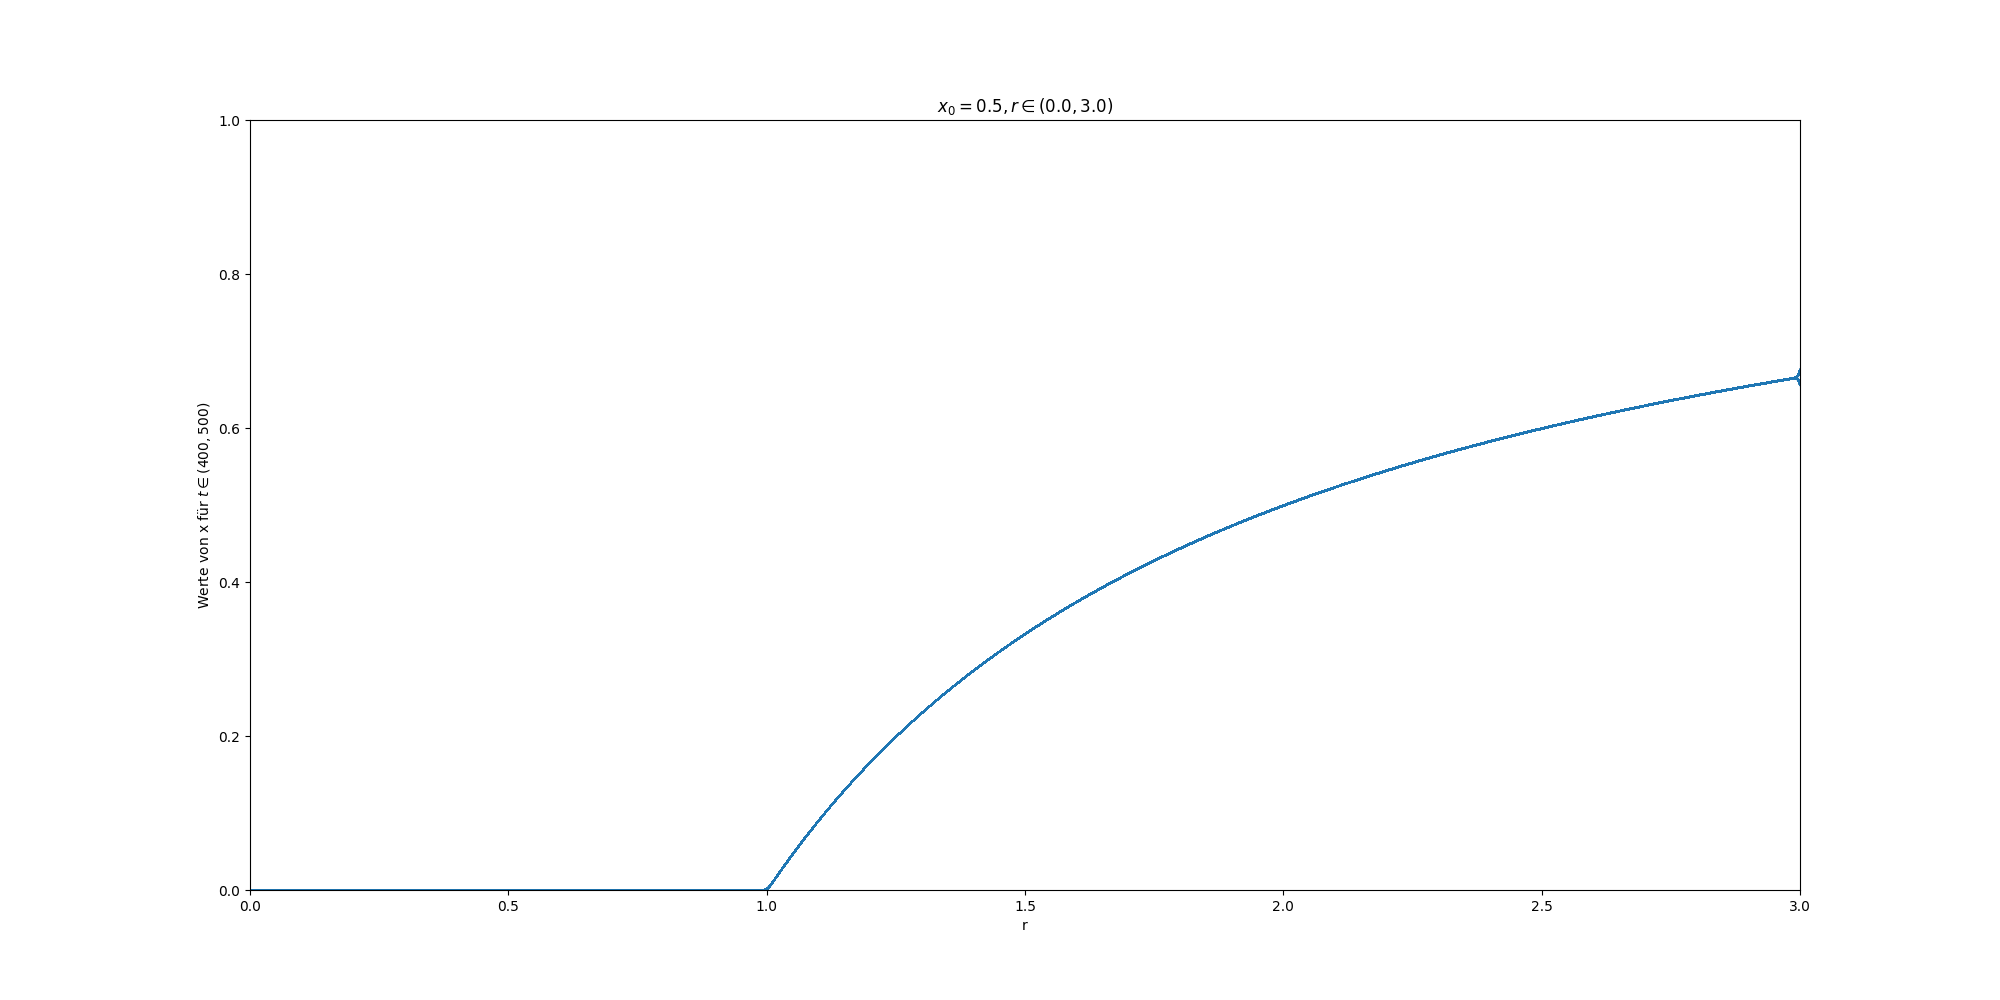

In [24]:
ax = plot_orbit_diagram(r_values=(0, 3),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=400, n_iterations_to_plot_until=500, labelsize=0.001)

In [ ]:
ax = plot_orbit_diagram(r_values=(0, 3.4),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=400, n_iterations_to_plot_until=500, labelsize=0.001)

In [ ]:
ax = plot_orbit_diagram(r_values=(0, 3.5),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=400, n_iterations_to_plot_until=500, labelsize=0.001)

In [ ]:
ax = plot_orbit_diagram(r_values=(0, 4),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=100, n_iterations_to_plot_until=200, labelsize=0.001)

In [ ]:
ax = plot_orbit_diagram(r_values=(3.4, 4),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=100, n_iterations_to_plot_until=200, labelsize=0.004)
import matplotlib.patches as patches
rect = patches.Rectangle((3.847, 0.13), 0.01, 0.035, linewidth=1, edgecolor='r', facecolor='none')
patch = ax.add_patch(rect)

In [ ]:
ax = plot_orbit_diagram(r_values=(3.847, 3.857),r_value_distance=0.0000001, x0=0.5, n_iterations_to_plot_from=200, n_iterations_to_plot_until=300, labelsize=0.0002)
plt.ylim(0.13,0.175)
rect = patches.Rectangle((3.85394, 0.16625), -3.85394+3.85409, -0.16625+0.16775, linewidth=1, edgecolor='r', facecolor='none')
patch = ax.add_patch(rect)

In [ ]:
plot_orbit_diagram(r_values=(3.85394, 3.85409),r_value_distance=0.00000001, x0=0.5, n_iterations_to_plot_from=2000, n_iterations_to_plot_until=2300, labelsize=0.02)
lims = plt.ylim(0.16625,0.16775)

In [ ]:
plot_orbit_diagram(r_values=(3.854073, 3.85408),r_value_distance=0.000000001, x0=0.5, n_iterations_to_plot_from=2000, n_iterations_to_plot_until=2300, labelsize=0.02, figsize=(8,5))
lims = plt.ylim(0.16625,0.16645)

In [ ]:
# point of interest:
# 

## Universalität und Feigenbaumkonstante


Abbildung $x_{t+1}=\frac{r}{4} \sin(\pi x_t)$ an. (immer orange) \
Wie sieht die aus im Vergleich zur logistischen Abbildung?

In [ ]:
ax=plot_orbit_diagram(r_values=(0, 4),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=100, n_iterations_to_plot_until=200, labelsize=0.001, color="tab:orange", discrete_map=iterate_sine_growth_function)

im Vergleich zu $rx(1-x)$

In [ ]:
ax = plot_orbit_diagram(r_values=(0, 4),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=100, n_iterations_to_plot_until=200, labelsize=0.001)
plot_orbit_diagram(r_values=(0, 4),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=100, n_iterations_to_plot_until=200, labelsize=0.001, discrete_map=iterate_sine_growth_function, color="tab:orange", ax=ax)


In [ ]:
ax = plot_orbit_diagram(r_values=(2.7, 4),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=100, n_iterations_to_plot_until=200, labelsize=0.001)
plot_orbit_diagram(r_values=(2.7, 4),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=100, n_iterations_to_plot_until=200, labelsize=0.001, discrete_map=iterate_sine_growth_function, color="tab:orange", ax=ax)


In [ ]:
ax = plot_orbit_diagram(r_values=(2.9, 3.6),r_value_distance=0.0001, x0=0.5, n_iterations_to_plot_from=1000, n_iterations_to_plot_until=1100, labelsize=0.001)
vals = [3.,3.449, 3.543, 3.564]
ax.vlines(vals, 0,1, colors="r")
old_ticks =[round(a, 4) for a in ax.get_xticks()]
old_labels = old_ticks.copy()
old_ticks.extend(vals)
old_labels.extend(["$r_1$", "$r_2$", "$r_3$", "$r_4$"])
ticks = ax.set_xticks(old_ticks, old_labels)